In [ ]:
pip install -U torch scikit-learn pandas numpy matplotlib seaborn transformers[accelerate,torch] accelerate evaluate datasets

In [3]:
import torch
import numpy as np

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import pandas as pd
import re
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
df = pd.read_csv('/content/processed_dataset_V1.csv')
print("Dataset loaded successfully. First 5 rows:")
print(df.head())

# 2. Clean the 'patient_data' column
def clean_text(text):
    text = str(text).lower()  
    text = re.sub(r'[^À-ſ -~]', '', text) 
    text = re.sub(r'[\W_]+', ' ', text)  
    text = re.sub(r'\d+', '', text)  
    text = re.sub(r'\s+', ' ', text).strip() 
    return text

df['patient_data'] = df['patient_data'].apply(clean_text)
print("\n'patient_data' column cleaned. First 5 cleaned entries:")
print(df['patient_data'].head().tolist())

# 3. Encode the 'label' column
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# 4. Create label mappings
label_to_id = {label: i for i, label in enumerate(label_encoder.classes_)}
id_to_label = {i: label for i, label in enumerate(label_encoder.classes_)}

print("\n'label' column encoded. First 5 original and encoded labels:")
print(df[['label', 'label_encoded']].head())
print(f"\nLabel to ID mapping: {label_to_id}")
print(f"ID to Label mapping: {id_to_label}")

Dataset loaded successfully. First 5 rows:
   Unnamed: 0  id  label                                       patient_data  \
0           0   1      0  Age : 70years; descriptions : - lv a cavity si...   
1           1   2      0  Age : 45 years; measurements : - ivst mm - 35 ...   
2           2   3      0  Age : 50years; descriptions : - lv a cavity si...   
3           3   4      0  Age : 48 years; descriptions : - lv a cavity s...   
4           4   5      1  Age : 65 years; descriptions : la - normal, rv...   

                                       combined_text  
0  Age : 70years; descriptions : - lv a cavity si...  
1  Age : 45 years; measurements : - ivst mm - 35 ...  
2  Age : 50years; descriptions : - lv a cavity si...  
3  Age : 48 years; descriptions : - lv a cavity s...  
4  Age : 65 years; descriptions : la - normal, rv...  

'patient_data' column cleaned. First 5 cleaned entries:
['age years descriptions lv a cavity size normal wall thickness normal wall motion normal other

In [ ]:
import sys
!{sys.executable} -m pip install -U imbalanced-learn

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

# RandomOverSampler
ros = RandomOverSampler(random_state=SEED)


X_resampled, y_resampled = ros.fit_resample(df[['patient_data']], df['label_encoded'])

print(f"Original label distribution: {df['label_encoded'].value_counts()}")
print(f"Resampled label distribution: {y_resampled.value_counts()}\n")

# Split the balanced dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=SEED, stratify=y_resampled
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Training label distribution:\n{y_train.value_counts()}")
print(f"Validation label distribution:\n{y_val.value_counts()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 19.5 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.0
    Uninstalling imbalanced-learn-0.14.0:
      Successfully uninstalled imbalanced-learn-0.14.0
Original label distribution: label_encoded
0    373
2    144
1    123
3     39
Name: count, dtype: int64
Resampled label distribution: label_encoded
0    373
1    373
2    373
3    373
Name: count, dtype: int64

Training set size: 1193 samples
Validation set size: 299 samples
Training label distribution:
label_encoded
1    299
2    298
0    298
3    298
Name: count, dtype: int64
Validation label distribution:
label_encoded
3    75
0    75
2    75
1    74
Name: count, dtype: int64


## Early Fusion Model and Dataset Setup




In [ ]:
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from torch.utils.data import Dataset
import torch


class EarlyFusionModel(nn.Module):
    def __init__(self, num_labels):
        super(EarlyFusionModel, self).__init__()
        # Load BioBERT
        self.biobert = AutoModel.from_pretrained('dmis-lab/biobert-v1.1')
        # Load ClinicalBERT
        self.clinicalbert = AutoModel.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')

        
        hidden_size_biobert = self.biobert.config.hidden_size
        hidden_size_clinicalbert = self.clinicalbert.config.hidden_size

        self.classifier = nn.Linear(hidden_size_biobert + hidden_size_clinicalbert, num_labels)

    def forward(self, biobert_input_ids, biobert_attention_mask, biobert_token_type_ids,
                clinicalbert_input_ids, clinicalbert_attention_mask, clinicalbert_token_type_ids):

        # BioBERT outputs
        biobert_outputs = self.biobert(input_ids=biobert_input_ids,
                                       attention_mask=biobert_attention_mask,
                                       token_type_ids=biobert_token_type_ids)
        biobert_pooled_output = biobert_outputs.pooler_output

        # ClinicalBERT outputs
        clinicalbert_outputs = self.clinicalbert(input_ids=clinicalbert_input_ids,
                                                  attention_mask=clinicalbert_attention_mask,
                                                  token_type_ids=clinicalbert_token_type_ids)
        clinicalbert_pooled_output = clinicalbert_outputs.pooler_output

        # Concatenate pooled outputs
        combined_pooled_output = torch.cat((biobert_pooled_output, clinicalbert_pooled_output), dim=1)

        # Pass through classifier
        logits = self.classifier(combined_pooled_output)
        return logits

# 2. EarlyFusionDataset class
class EarlyFusionDataset(Dataset):
    def __init__(self, texts, labels, biobert_tokenizer, clinicalbert_tokenizer, max_length=128):
        self.texts = texts.tolist() if isinstance(texts, pd.Series) else texts
        self.labels = labels.tolist() if isinstance(labels, pd.Series) else labels
        self.biobert_tokenizer = biobert_tokenizer
        self.clinicalbert_tokenizer = clinicalbert_tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize with BioBERT
        biobert_encoding = self.biobert_tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True,
            return_tensors='pt'
        )

        # Tokenize with ClinicalBERT
        clinicalbert_encoding = self.clinicalbert_tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True,
            return_tensors='pt'
        )

        return {
            'biobert_input_ids': biobert_encoding['input_ids'].flatten(),
            'biobert_attention_mask': biobert_encoding['attention_mask'].flatten(),
            'biobert_token_type_ids': biobert_encoding['token_type_ids'].flatten(),
            'clinicalbert_input_ids': clinicalbert_encoding['input_ids'].flatten(),
            'clinicalbert_attention_mask': clinicalbert_encoding['attention_mask'].flatten(),
            'clinicalbert_token_type_ids': clinicalbert_encoding['token_type_ids'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# 3. the simple_collate_fn function
def simple_collate_fn(batch):
    biobert_input_ids = torch.stack([item['biobert_input_ids'] for item in batch])
    biobert_attention_mask = torch.stack([item['biobert_attention_mask'] for item in batch])
    biobert_token_type_ids = torch.stack([item['biobert_token_type_ids'] for item in batch])
    clinicalbert_input_ids = torch.stack([item['clinicalbert_input_ids'] for item in batch])
    clinicalbert_attention_mask = torch.stack([item['clinicalbert_attention_mask'] for item in batch])
    clinicalbert_token_type_ids = torch.stack([item['clinicalbert_token_type_ids'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])

    return {
        'biobert_input_ids': biobert_input_ids,
        'biobert_attention_mask': biobert_attention_mask,
        'biobert_token_type_ids': biobert_token_type_ids,
        'clinicalbert_input_ids': clinicalbert_input_ids,
        'clinicalbert_attention_mask': clinicalbert_attention_mask,
        'clinicalbert_token_type_ids': clinicalbert_token_type_ids,
        'labels': labels
    }

# 4.tokenizers
biobert_tokenizer = AutoTokenizer.from_pretrained('dmis-lab/biobert-v1.1')
clinicalbert_tokenizer = AutoTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')
print("Tokenizers initialized.")

# 5. Create the datasets
MAX_LENGTH = 128 
num_labels = len(id_to_label) 

train_dataset_early = EarlyFusionDataset(
    texts=X_train['patient_data'],
    labels=y_train,
    biobert_tokenizer=biobert_tokenizer,
    clinicalbert_tokenizer=clinicalbert_tokenizer,
    max_length=MAX_LENGTH
)

val_dataset_early = EarlyFusionDataset(
    texts=X_val['patient_data'],
    labels=y_val,
    biobert_tokenizer=biobert_tokenizer,
    clinicalbert_tokenizer=clinicalbert_tokenizer,
    max_length=MAX_LENGTH
)

print(f"Early Fusion Training Dataset created with {len(train_dataset_early)} samples.")
print(f"Early Fusion Validation Dataset created with {len(val_dataset_early)} samples.")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizers initialized.
Early Fusion Training Dataset created with 1193 samples.
Early Fusion Validation Dataset created with 299 samples.


In [ ]:
from torch.utils.data import DataLoader
from torch.optim import AdamW

# the EarlyFusionModel
model_early = EarlyFusionModel(num_labels=num_labels)
model_early.to(device)

#  optimizer and loss function
optimizer_early = AdamW(model_early.parameters(), lr=2e-5)
criterion_early = nn.CrossEntropyLoss()

print(f"EarlyFusionModel instantiated and moved to {device}.")
print("Optimizer (AdamW) and Loss function (CrossEntropyLoss) defined.")

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

EarlyFusionModel instantiated and moved to cuda.
Optimizer (AdamW) and Loss function (CrossEntropyLoss) defined.


In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_dataloader_early = DataLoader(
    train_dataset_early,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=simple_collate_fn
)

val_dataloader_early = DataLoader(
    val_dataset_early,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=simple_collate_fn
)

print(f"Early Fusion Training DataLoader created with batch size {BATCH_SIZE}.")
print(f"Early Fusion Validation DataLoader created with batch size {BATCH_SIZE}.")

Early Fusion Training DataLoader created with batch size 16.
Early Fusion Validation DataLoader created with batch size 16.


## Early Fusion Model Training




In [ ]:
import torch
import evaluate
from tqdm.notebook import tqdm

class CleanTableTrainer:
    def __init__(self, model, optimizer, criterion, train_dataloader, val_dataloader, device, num_labels, patience=3):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.train_dataloader = train_dataloader
        self.val_dataloader = val_dataloader
        self.device = device
        self.num_labels = num_labels

        self.metric_accuracy = evaluate.load("accuracy")
        self.metric_f1 = evaluate.load("f1")

        self.patience = patience
        self.best_val_loss = float('inf')
        self.epochs_no_improve = 0

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_accuracy': [],
            'val_f1_score': []
        }

    def _train_epoch(self):
        self.model.train()
        total_loss = 0
        for batch in tqdm(self.train_dataloader, desc="Training"): 
            self.optimizer.zero_grad()

            biobert_input_ids = batch['biobert_input_ids'].to(self.device)
            biobert_attention_mask = batch['biobert_attention_mask'].to(self.device)
            biobert_token_type_ids = batch['biobert_token_type_ids'].to(self.device)
            clinicalbert_input_ids = batch['clinicalbert_input_ids'].to(self.device)
            clinicalbert_attention_mask = batch['clinicalbert_attention_mask'].to(self.device)
            clinicalbert_token_type_ids = batch['clinicalbert_token_type_ids'].to(self.device)
            labels = batch['labels'].to(self.device)

            outputs = self.model(
                biobert_input_ids=biobert_input_ids,
                biobert_attention_mask=biobert_attention_mask,
                biobert_token_type_ids=biobert_token_type_ids,
                clinicalbert_input_ids=clinicalbert_input_ids,
                clinicalbert_attention_mask=clinicalbert_attention_mask,
                clinicalbert_token_type_ids=clinicalbert_token_type_ids
            )

            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()

        return total_loss / len(self.train_dataloader)

    def _evaluate(self):
        self.model.eval()
        total_loss = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for batch in tqdm(self.val_dataloader, desc="Evaluation"): 
                biobert_input_ids = batch['biobert_input_ids'].to(self.device)
                biobert_attention_mask = batch['biobert_attention_mask'].to(self.device)
                biobert_token_type_ids = batch['biobert_token_type_ids'].to(self.device)
                clinicalbert_input_ids = batch['clinicalbert_input_ids'].to(self.device)
                clinicalbert_attention_mask = batch['clinicalbert_attention_mask'].to(self.device)
                clinicalbert_token_type_ids = batch['clinicalbert_token_type_ids'].to(self.device)
                labels = batch['labels'].to(self.device)

                outputs = self.model(
                    biobert_input_ids=biobert_input_ids,
                    biobert_attention_mask=biobert_attention_mask,
                    biobert_token_type_ids=biobert_token_type_ids,
                    clinicalbert_input_ids=clinicalbert_input_ids,
                    clinicalbert_attention_mask=clinicalbert_attention_mask,
                    clinicalbert_token_type_ids=clinicalbert_token_type_ids
                )

                loss = self.criterion(outputs, labels)
                total_loss += loss.item()

                predictions = torch.argmax(outputs, dim=-1)
                all_predictions.extend(predictions.cpu().tolist())
                all_labels.extend(labels.cpu().tolist())

        val_accuracy = self.metric_accuracy.compute(predictions=all_predictions, references=all_labels)['accuracy']
        val_f1_score = self.metric_f1.compute(predictions=all_predictions, references=all_labels, average='weighted')['f1']

        return total_loss / len(self.val_dataloader), val_accuracy, val_f1_score

    def train(self, epochs):
        print("Starting training...")
        for epoch in range(epochs):
            train_loss = self._train_epoch()
            val_loss, val_accuracy, val_f1_score = self._evaluate()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_accuracy'].append(val_accuracy)
            self.history['val_f1_score'].append(val_f1_score)

            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f} | Val F1: {val_f1_score:.4f}")

            # Early stopping 
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.epochs_no_improve = 0
               
                torch.save(self.model.state_dict(), 'early_fusion_model_best.pt')
                print("Saved best model with validation loss: {self.best_val_loss:.4f}")
            else:
                self.epochs_no_improve += 1
                if self.epochs_no_improve == self.patience:
                    print(f"Early stopping triggered after {self.patience} epochs with no improvement.")
                    break

        print("Training complete.")
        # Save the final model state 
        torch.save(self.model.state_dict(), 'early_fusion_model_final.pt')
        print("Final model state saved to early_fusion_model_final.pt")

EPOCHS = 10  
trainer_early = CleanTableTrainer(
    model=model_early,
    optimizer=optimizer_early,
    criterion=criterion_early,
    train_dataloader=train_dataloader_early,
    val_dataloader=val_dataloader_early,
    device=device,
    num_labels=num_labels
)


trainer_early.train(epochs=EPOCHS)

print("Training history:", trainer_early.history)


Starting training...


Training:   0%|          | 0/75 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 0.9144 | Val Loss: 0.5522 | Val Acc: 0.7425 | Val F1: 0.7317
Saved best model with validation loss: {self.best_val_loss:.4f}


Training:   0%|          | 0/75 [00:00<?, ?it/s]

...

Evaluation:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.0687 | Val Loss: 0.0627 | Val Acc: 0.9799 | Val F1: 0.9800


Training:   0%|          | 0/75 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.0527 | Val Loss: 0.0379 | Val Acc: 0.9900 | Val F1: 0.9900
Training complete.
Final model state saved to early_fusion_model_final.pt
Training history: {'train_loss': [0.9144091510772705, 0.4156361974279086, 0.257690563450257, 0.13797626083095868, 0.08062807928770781, 0.0792173310990135, 0.03729513664729893, 0.04193617309443653, 0.06874325533707937, 0.05273046079402169], 'val_loss': [0.552150223600237, 0.26513637014125524, 0.17944868575585515, 0.062040562496373526, 0.10073001101907146, 0.07453346203424428, 0.061242945259436965, 0.03516421566325191, 0.06270192293940406, 0.03787323698940638], 'val_accuracy': [0.7424749163879598, 0.9063545150501672, 0.919732441471572, 0.9832775919732442, 0.9632107023411371, 0.979933110367893, 0.979933110367893, 0.9866220735785953, 0.979933110367893, 0.9899665551839465], 'val_f1_score': [0.7316914815776794, 0.9040847219048008, 0.9195939844009688, 0.9832971949950531, 0.9632445590176216, 0.9799289231673796, 0.9799261173826549, 0.98

## Late Fusion Model and Individual Dataset Setup




In [ ]:
import torch.nn as nn
from transformers import AutoModelForSequenceClassification
from datasets import Dataset
import pandas as pd


class LateFusionModel(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.biobert_model = AutoModelForSequenceClassification.from_pretrained('dmis-lab/biobert-v1.1', num_labels=num_labels)
        self.clinicalbert_model = AutoModelForSequenceClassification.from_pretrained('emilyalsentzer/Bio_ClinicalBERT', num_labels=num_labels)
        print("LateFusionModel initialized with BioBERT and ClinicalBERT as AutoModelForSequenceClassification components.")

    def forward(self, *args, **kwargs):
  
        raise NotImplementedError("This LateFusionModel class is a placeholder for model instantiation. Individual models are trained separately.")


def tokenize_function_biobert(examples):
    return biobert_tokenizer(
        examples['text'],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

def tokenize_function_clinicalbert(examples):
    return clinicalbert_tokenizer(
        examples['text'],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

# Prepare data for Hugging Face Dataset objects
train_data_for_hf = {'text': X_train['patient_data'].tolist(), 'labels': y_train.tolist()}
val_data_for_hf = {'text': X_val['patient_data'].tolist(), 'labels': y_val.tolist()}

raw_train_dataset_hf = Dataset.from_dict(train_data_for_hf)
raw_val_dataset_hf = Dataset.from_dict(val_data_for_hf)

# Create HuggingFace Dataset objects for BioBERT
train_dataset_biobert = raw_train_dataset_hf.map(tokenize_function_biobert, batched=True)
val_dataset_biobert = raw_val_dataset_hf.map(tokenize_function_biobert, batched=True)

# Remove the original 'text' column and set format to PyTorch tensors
train_dataset_biobert = train_dataset_biobert.remove_columns(['text'])
val_dataset_biobert = val_dataset_biobert.remove_columns(['text'])
train_dataset_biobert.set_format(type="torch", columns=['input_ids', 'attention_mask', 'token_type_ids', 'labels'])
val_dataset_biobert.set_format(type="torch", columns=['input_ids', 'attention_mask', 'token_type_ids', 'labels'])

print(f"BioBERT Training Dataset created with {len(train_dataset_biobert)} samples.")
print(f"BioBERT Validation Dataset created with {len(val_dataset_biobert)} samples.")

# Create HuggingFace Dataset objects for ClinicalBERT
train_dataset_clinicalbert = raw_train_dataset_hf.map(tokenize_function_clinicalbert, batched=True)
val_dataset_clinicalbert = raw_val_dataset_hf.map(tokenize_function_clinicalbert, batched=True)

# Remove the original 'text' column and set format to PyTorch tensors
train_dataset_clinicalbert = train_dataset_clinicalbert.remove_columns(['text'])
val_dataset_clinicalbert = val_dataset_clinicalbert.remove_columns(['text'])
train_dataset_clinicalbert.set_format(type="torch", columns=['input_ids', 'attention_mask', 'token_type_ids', 'labels'])
val_dataset_clinicalbert.set_format(type="torch", columns=['input_ids', 'attention_mask', 'token_type_ids', 'labels'])

print(f"ClinicalBERT Training Dataset created with {len(train_dataset_clinicalbert)} samples.")
print(f"ClinicalBERT Validation Dataset created with {len(val_dataset_clinicalbert)} samples.")


Map:   0%|          | 0/1193 [00:00<?, ? examples/s]

Map:   0%|          | 0/299 [00:00<?, ? examples/s]

BioBERT Training Dataset created with 1193 samples.
BioBERT Validation Dataset created with 299 samples.


Map:   0%|          | 0/1193 [00:00<?, ? examples/s]

Map:   0%|          | 0/299 [00:00<?, ? examples/s]

ClinicalBERT Training Dataset created with 1193 samples.
ClinicalBERT Validation Dataset created with 299 samples.


## Late Fusion Individual Model Training




In [ ]:
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
from transformers import AutoModelForSequenceClassification
import evaluate
import numpy as np

# 1. Define the compute_metrics function
def compute_metrics(pred):
    labels = pred.label_ids
    predictions = pred.predictions.argmax(-1)

    metric_accuracy = evaluate.load("accuracy")
    metric_f1 = evaluate.load("f1")

    accuracy = metric_accuracy.compute(predictions=predictions, references=labels)['accuracy']
    f1_score = metric_f1.compute(predictions=predictions, references=labels, average='weighted')['f1']

    return {"accuracy": accuracy, "f1": f1_score}

print("compute_metrics function defined.")

# BioBERT Model Training 

# BioBERT model
model_biobert = AutoModelForSequenceClassification.from_pretrained('dmis-lab/biobert-v1.1', num_labels=num_labels)
model_biobert.to(device)
print(f"BioBERT model instantiated and moved to {device}.")

# TrainingArguments for BioBERT
training_args_biobert = TrainingArguments(
    output_dir='./results_biobert',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs_biobert',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to="none" 
)
print("TrainingArguments for BioBERT configured.")

# EarlyStoppingCallback
early_stopping_callback = EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.01)
print("EarlyStoppingCallback instantiated.")

# Trainer for BioBERT
trainer_biobert = Trainer(
    model=model_biobert,
    args=training_args_biobert,
    train_dataset=train_dataset_biobert,
    eval_dataset=val_dataset_biobert,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback],
)
print("Trainer for BioBERT instantiated.")

#  BioBERT model
print("Starting BioBERT model training...")
trainer_biobert.train()
print("BioBERT model training complete.")

# Save the trained BioBERT model and tokenizer
trainer_biobert.save_model('./biobert_individual')
biobert_tokenizer.save_pretrained('./biobert_individual')
print("BioBERT model and tokenizer saved to './biobert_individual'.")

# ClinicalBERT Model Training 

# ClinicalBERT model
model_clinicalbert = AutoModelForSequenceClassification.from_pretrained('emilyalsentzer/Bio_ClinicalBERT', num_labels=num_labels)
model_clinicalbert.to(device)
print(f"ClinicalBERT model instantiated and moved to {device}.")

# TrainingArguments for ClinicalBERT
training_args_clinicalbert = TrainingArguments(
    output_dir='./results_clinicalbert',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs_clinicalbert',
    logging_steps=100,
    eval_strategy='epoch', 
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to="none" 
)
print("TrainingArguments for ClinicalBERT configured.")

# Trainer for ClinicalBERT
trainer_clinicalbert = Trainer(
    model=model_clinicalbert,
    args=training_args_clinicalbert,
    train_dataset=train_dataset_clinicalbert,
    eval_dataset=val_dataset_clinicalbert,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback],
)
print("Trainer for ClinicalBERT instantiated.")

# ClinicalBERT model
print("Starting ClinicalBERT model training...")
trainer_clinicalbert.train()
print("ClinicalBERT model training complete.")

# Save the trained ClinicalBERT model and tokenizer
trainer_clinicalbert.save_model('./clinicalbert_individual')
clinicalbert_tokenizer.save_pretrained('./clinicalbert_individual')
print("ClinicalBERT model and tokenizer saved to './clinicalbert_individual'.")

compute_metrics function defined.


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BioBERT model instantiated and moved to cuda.
TrainingArguments for BioBERT configured.
EarlyStoppingCallback instantiated.
Trainer for BioBERT instantiated.
Starting BioBERT model training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.202353,0.501672,0.465109
2,1.291500,0.601419,0.749164,0.746962
3,0.687700,0.408501,0.869565,0.867916
4,0.376100,0.277592,0.903010,0.902774
5,0.376100,0.196221,0.936455,0.936162
6,0.267700,0.330342,0.882943,0.881646
7,0.192700,0.167432,0.943144,0.942642
8,0.158500,0.179462,0.939799,0.939628


BioBERT model training complete.
BioBERT model and tokenizer saved to './biobert_individual'.


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ClinicalBERT model instantiated and moved to cuda.
TrainingArguments for ClinicalBERT configured.
Trainer for ClinicalBERT instantiated.
Starting ClinicalBERT model training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.213581,0.488294,0.463296
2,1.282100,0.650008,0.802676,0.798172
3,0.769600,0.401932,0.879599,0.879633
4,0.351500,0.212635,0.913043,0.911709
5,0.351500,0.188959,0.943144,0.942868
6,0.227700,0.165629,0.953177,0.953008
7,0.157100,0.138865,0.953177,0.953092
8,0.135800,0.138611,0.959866,0.959903
9,0.135800,0.074145,0.979933,0.979930
10,0.056100,0.071305,0.983278,0.983275


ClinicalBERT model training complete.
ClinicalBERT model and tokenizer saved to './clinicalbert_individual'.


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification
import evaluate
from tqdm.notebook import tqdm
import numpy as np

# Load the trained individual models
model_biobert_loaded = AutoModelForSequenceClassification.from_pretrained('./biobert_individual')
model_clinicalbert_loaded = AutoModelForSequenceClassification.from_pretrained('./clinicalbert_individual')

# Move models to the device
model_biobert_loaded.to(device)
model_clinicalbert_loaded.to(device);

print("Trained BioBERT and ClinicalBERT models loaded successfully.")

# LateFusionClassifier

class LateFusionClassifier:
    def __init__(self, biobert_model, clinicalbert_model, num_labels):
        self.biobert_model = biobert_model
        self.clinicalbert_model = clinicalbert_model
        self.num_labels = num_labels

    def combine_predictions(self, biobert_outputs, clinicalbert_outputs):
        
        biobert_logits = biobert_outputs.predictions
        clinicalbert_logits = clinicalbert_outputs.predictions

        
        biobert_logits_tensor = torch.tensor(biobert_logits, device=device)
        clinicalbert_logits_tensor = torch.tensor(clinicalbert_logits, device=device)

        combined_logits = (biobert_logits_tensor + clinicalbert_logits_tensor) / 2
        return combined_logits


def predict_late_fusion(late_fusion_classifier, val_dataset_biobert, val_dataset_clinicalbert, trainer_biobert, trainer_clinicalbert):
    
    late_fusion_classifier.biobert_model.eval()
    late_fusion_classifier.clinicalbert_model.eval()

 
    biobert_val_outputs = trainer_biobert.predict(val_dataset_biobert)
    clinicalbert_val_outputs = trainer_clinicalbert.predict(val_dataset_clinicalbert)

 
    combined_logits = late_fusion_classifier.combine_predictions(biobert_val_outputs, clinicalbert_val_outputs)

  
    final_predictions = torch.argmax(combined_logits, dim=-1).cpu().numpy()
    true_labels = biobert_val_outputs.label_ids 

    return final_predictions, true_labels


late_fusion_model_instance = LateFusionClassifier(model_biobert_loaded, model_clinicalbert_loaded, num_labels)
print("LateFusionClassifier instance created.")


late_fusion_predictions, late_fusion_true_labels = predict_late_fusion(
    late_fusion_model_instance,
    val_dataset_biobert,
    val_dataset_clinicalbert,
    trainer_biobert, 
    trainer_clinicalbert
)
print("Late fusion predictions obtained.")

# Evaluate performance
metric_accuracy = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

late_fusion_accuracy = metric_accuracy.compute(predictions=late_fusion_predictions, references=late_fusion_true_labels)['accuracy']
late_fusion_f1_score = metric_f1.compute(predictions=late_fusion_predictions, references=late_fusion_true_labels, average='weighted')['f1']

print(f"\nLate Fusion Model - Validation Accuracy: {late_fusion_accuracy:.4f}")
print(f"Late Fusion Model - Validation F1-score: {late_fusion_f1_score:.4f}")

Trained BioBERT and ClinicalBERT models loaded successfully.
LateFusionClassifier instance created.


Late fusion predictions obtained.

Late Fusion Model - Validation Accuracy: 0.9833
Late Fusion Model - Validation F1-score: 0.9833


In [ ]:
import pandas as pd


best_val_loss_early = min(trainer_early.history['val_loss'])
best_epoch_index_early = trainer_early.history['val_loss'].index(best_val_loss_early)
early_fusion_best_accuracy = trainer_early.history['val_accuracy'][best_epoch_index_early]
early_fusion_best_f1_score = trainer_early.history['val_f1_score'][best_epoch_index_early]

print(f"Early Fusion Best Validation Accuracy: {early_fusion_best_accuracy:.4f}")
print(f"Early Fusion Best Validation F1-score: {early_fusion_best_f1_score:.4f}\n")


biobert_eval_results = trainer_biobert.evaluate(val_dataset_biobert)
biobert_best_accuracy = biobert_eval_results['eval_accuracy']
biobert_best_f1_score = biobert_eval_results['eval_f1']

print(f"Individual BioBERT Best Validation Accuracy: {biobert_best_accuracy:.4f}")
print(f"Individual BioBERT Best Validation F1-score: {biobert_best_f1_score:.4f}\n")


clinicalbert_eval_results = trainer_clinicalbert.evaluate(val_dataset_clinicalbert)
clinicalbert_best_accuracy = clinicalbert_eval_results['eval_accuracy']
clinicalbert_best_f1_score = clinicalbert_eval_results['eval_f1']

print(f"Individual ClinicalBERT Best Validation Accuracy: {clinicalbert_best_accuracy:.4f}")
print(f"Individual ClinicalBERT Best Validation F1-score: {clinicalbert_best_f1_score:.4f}\n")


print(f"Late Fusion Model - Validation Accuracy: {late_fusion_accuracy:.4f}")
print(f"Late Fusion Model - Validation F1-score: {late_fusion_f1_score:.4f}\n")

# summary table of all metrics
results = {
    "Model/Strategy": ["Early Fusion", "Individual BioBERT", "Individual ClinicalBERT", "Late Fusion"],
    "Validation Accuracy": [
        early_fusion_best_accuracy,
        biobert_best_accuracy,
        clinicalbert_best_accuracy,
        late_fusion_accuracy
    ],
    "Validation F1-score": [
        early_fusion_best_f1_score,
        biobert_best_f1_score,
        clinicalbert_best_f1_score,
        late_fusion_f1_score
    ]
}

results_df = pd.DataFrame(results)
print("\n--- Performance Summary ---")
print(results_df.round(4))

best_performance_row = results_df.loc[results_df['Validation F1-score'].idxmax()]
print(f"\nBest performing strategy: {best_performance_row['Model/Strategy']} with F1-score of {best_performance_row['Validation F1-score']:.4f} and Accuracy of {best_performance_row['Validation Accuracy']:.4f}")


Early Fusion Best Validation Accuracy: 0.9866
Early Fusion Best Validation F1-score: 0.9866



Individual BioBERT Best Validation Accuracy: 0.9431
Individual BioBERT Best Validation F1-score: 0.9426



Individual ClinicalBERT Best Validation Accuracy: 0.9833
Individual ClinicalBERT Best Validation F1-score: 0.9833

Late Fusion Model - Validation Accuracy: 0.9833
Late Fusion Model - Validation F1-score: 0.9833


--- Performance Summary ---
            Model/Strategy  Validation Accuracy  Validation F1-score
0             Early Fusion               0.9866               0.9866
1       Individual BioBERT               0.9431               0.9426
2  Individual ClinicalBERT               0.9833               0.9833
3              Late Fusion               0.9833               0.9833

Best performing strategy: Early Fusion with F1-score of 0.9866 and Accuracy of 0.9866


## Comprehensive Model Evaluation



In [ ]:
import torch
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import evaluate
from transformers import PreTrainedModel 


# Load the best saved Early Fusion model
model_early_loaded = EarlyFusionModel(num_labels=num_labels) 
model_early_loaded.load_state_dict(torch.load('early_fusion_model_best.pt', map_location=device))
model_early_loaded.to(device)
model_early_loaded.eval()


model_biobert_loaded.eval()
model_clinicalbert_loaded.eval()

print("Best Early Fusion model loaded and all models set to evaluation mode.")


def get_predictions_and_probabilities(model, dataloader, device):
    model.eval()
    all_true_labels = []
    all_predictions = []
    all_probabilities = [] 

    with torch.no_grad():
        for batch in dataloader:
            labels = batch['labels'].to(device)

            if isinstance(model, EarlyFusionModel):
                outputs = model(
                    biobert_input_ids=batch['biobert_input_ids'].to(device),
                    biobert_attention_mask=batch['biobert_attention_mask'].to(device),
                    biobert_token_type_ids=batch['biobert_token_type_ids'].to(device),
                    clinicalbert_input_ids=batch['clinicalbert_input_ids'].to(device),
                    clinicalbert_attention_mask=batch['clinicalbert_attention_mask'].to(device),
                    clinicalbert_token_type_ids=batch['clinicalbert_token_type_ids'].to(device)
                )
                probabilities = torch.softmax(outputs, dim=-1)
            elif isinstance(model, PreTrainedModel): 
                outputs = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                    token_type_ids=batch['token_type_ids'].to(device)
                )
                probabilities = torch.softmax(outputs.logits, dim=-1)
            else:
                raise ValueError(f"Unsupported model type: {type(model)}") 

            predictions = torch.argmax(probabilities, dim=-1)

            all_true_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())
            all_probabilities.extend(probabilities.cpu().tolist())

    return all_true_labels, all_predictions, np.array(all_probabilities)

# DataLoaders for individual BioBERT and ClinicalBERT models
batch_size = BATCH_SIZE

biobert_val_dataloader = DataLoader(
    val_dataset_biobert,
    batch_size=batch_size,
    shuffle=False
)

clinicalbert_val_dataloader = DataLoader(
    val_dataset_clinicalbert,
    batch_size=batch_size,
    shuffle=False
)

# predictions and probabilities for the Early Fusion model
true_labels_early, predictions_early, probabilities_early = get_predictions_and_probabilities(
    model_early_loaded, val_dataloader_early, device
)
print("Predictions obtained for Early Fusion model.")

# predictions and probabilities for the individual BioBERT model
true_labels_biobert, predictions_biobert, probabilities_biobert = get_predictions_and_probabilities(
    model_biobert_loaded, biobert_val_dataloader, device
)
print("Predictions obtained for Individual BioBERT model.")

# predictions and probabilities for the individual ClinicalBERT model
true_labels_clinicalbert, predictions_clinicalbert, probabilities_clinicalbert = get_predictions_and_probabilities(
    model_clinicalbert_loaded, clinicalbert_val_dataloader, device
)
print("Predictions obtained for Individual ClinicalBERT model.")


assert np.array_equal(true_labels_early, true_labels_biobert)
assert np.array_equal(true_labels_early, true_labels_clinicalbert)
common_true_labels = true_labels_early


predictions_late_fusion_avg = late_fusion_predictions
print("Late Fusion (Averaging) predictions re-used from previous step.")


def majority_vote(preds):
    
    counts = np.bincount(preds)
    
    return np.argmax(counts)

predictions_late_fusion_voting = []
for i in range(len(common_true_labels)):
    
    votes = [predictions_biobert[i], predictions_clinicalbert[i]]
    predictions_late_fusion_voting.append(majority_vote(votes))

print("Late Fusion (Voting) predictions obtained.")

Best Early Fusion model loaded and all models set to evaluation mode.
Predictions obtained for Early Fusion model.
Predictions obtained for Individual BioBERT model.
Predictions obtained for Individual ClinicalBERT model.
Late Fusion (Averaging) predictions re-used from previous step.
Late Fusion (Voting) predictions obtained.



--- Evaluation for Early Fusion ---
Accuracy: 0.9866
F1-score (Weighted): 0.9866
F1-score (Macro): 0.9866
Precision (Weighted): 0.9867
Precision (Macro): 0.9868
Recall (Weighted): 0.9866
Recall (Macro): 0.9866
Cohen's Kappa: 0.9822
Matthews MCC: 0.9822

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        75
           1       1.00      0.99      0.99        74
           2       0.97      0.99      0.98        75
           3       0.99      1.00      0.99        75

    accuracy                           0.99       299
   macro avg       0.99      0.99      0.99       299
weighted avg       0.99      0.99      0.99       299



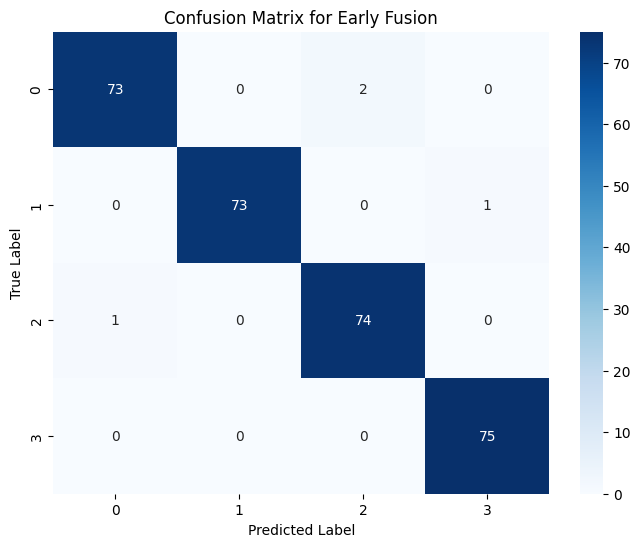


--- Evaluation for Individual BioBERT ---
Accuracy: 0.9431
F1-score (Weighted): 0.9426
F1-score (Macro): 0.9427
Precision (Weighted): 0.9469
Precision (Macro): 0.9470
Recall (Weighted): 0.9431
Recall (Macro): 0.9432
Cohen's Kappa: 0.9242
Matthews MCC: 0.9258

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93        75
           1       0.96      0.95      0.95        74
           2       0.98      0.84      0.91        75
           3       0.97      1.00      0.99        75

    accuracy                           0.94       299
   macro avg       0.95      0.94      0.94       299
weighted avg       0.95      0.94      0.94       299



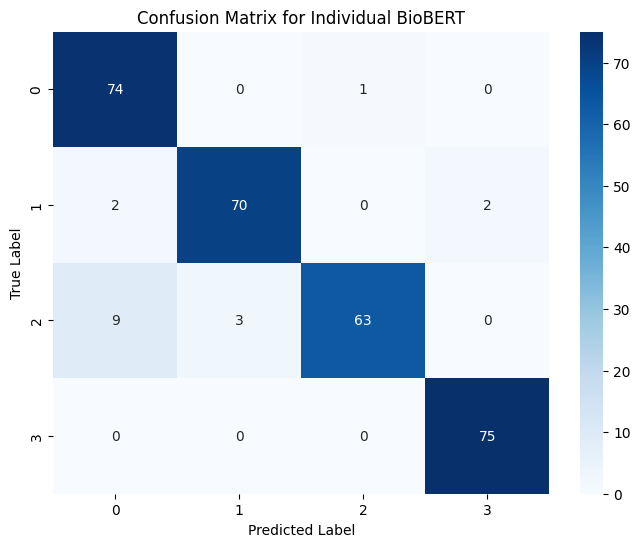


--- Evaluation for Individual ClinicalBERT ---
Accuracy: 0.9833
F1-score (Weighted): 0.9833
F1-score (Macro): 0.9833
Precision (Weighted): 0.9835
Precision (Macro): 0.9835
Recall (Weighted): 0.9833
Recall (Macro): 0.9833
Cohen's Kappa: 0.9777
Matthews MCC: 0.9778

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        75
           1       1.00      0.99      0.99        74
           2       0.96      0.99      0.97        75
           3       0.99      1.00      0.99        75

    accuracy                           0.98       299
   macro avg       0.98      0.98      0.98       299
weighted avg       0.98      0.98      0.98       299



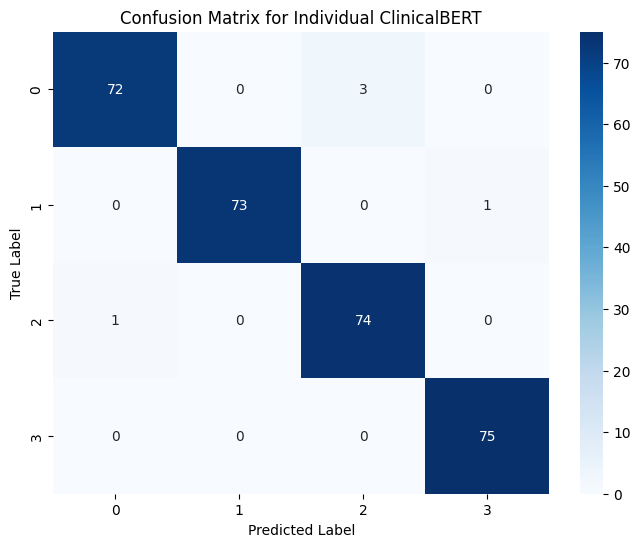


--- Evaluation for Late Fusion (Averaging) ---
Accuracy: 0.9833
F1-score (Weighted): 0.9833
F1-score (Macro): 0.9833
Precision (Weighted): 0.9835
Precision (Macro): 0.9835
Recall (Weighted): 0.9833
Recall (Macro): 0.9833
Cohen's Kappa: 0.9777
Matthews MCC: 0.9778

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        75
           1       1.00      0.99      0.99        74
           2       0.96      0.99      0.97        75
           3       0.99      1.00      0.99        75

    accuracy                           0.98       299
   macro avg       0.98      0.98      0.98       299
weighted avg       0.98      0.98      0.98       299



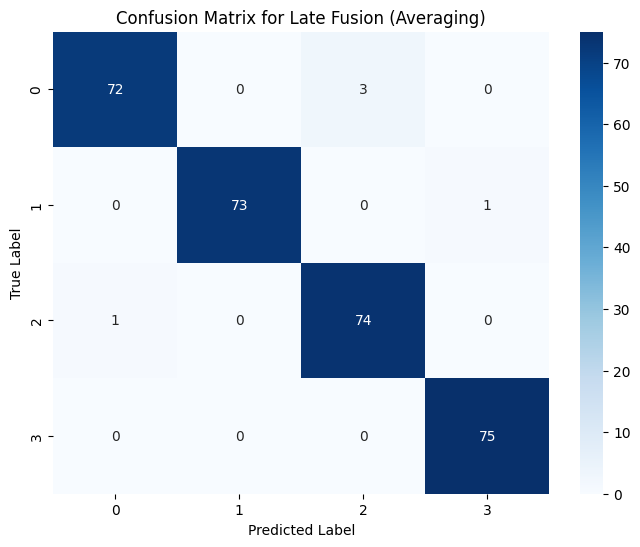


--- Evaluation for Late Fusion (Voting) ---
Accuracy: 0.9465
F1-score (Weighted): 0.9460
F1-score (Macro): 0.9461
Precision (Weighted): 0.9503
Precision (Macro): 0.9503
Recall (Weighted): 0.9465
Recall (Macro): 0.9465
Cohen's Kappa: 0.9287
Matthews MCC: 0.9302

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93        75
           1       0.96      0.96      0.96        74
           2       0.98      0.84      0.91        75
           3       0.99      1.00      0.99        75

    accuracy                           0.95       299
   macro avg       0.95      0.95      0.95       299
weighted avg       0.95      0.95      0.95       299



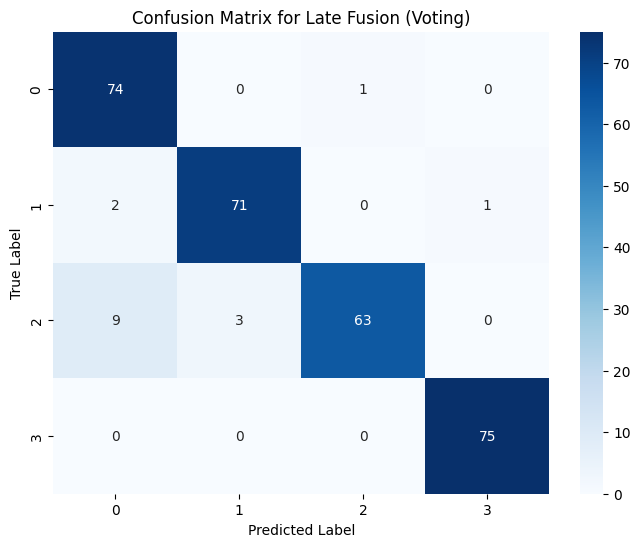


All model evaluation metrics saved to 'model_evaluation_metrics.csv'


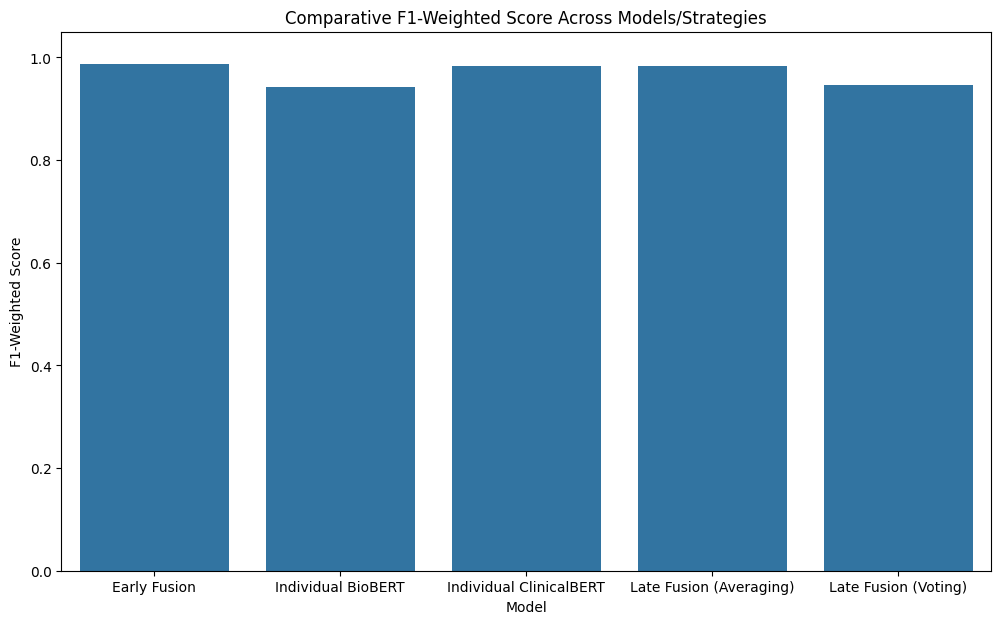

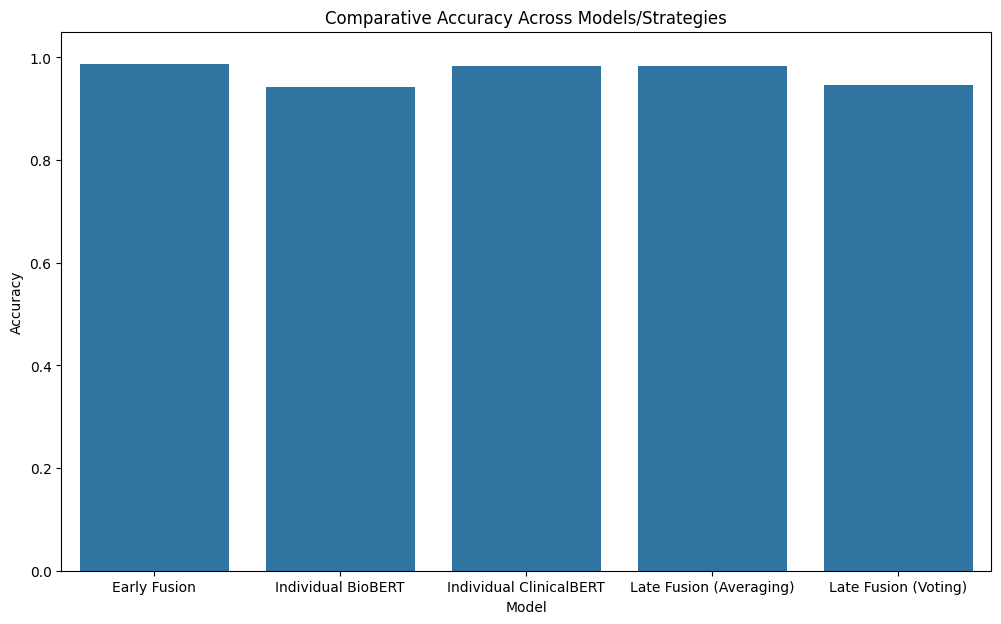

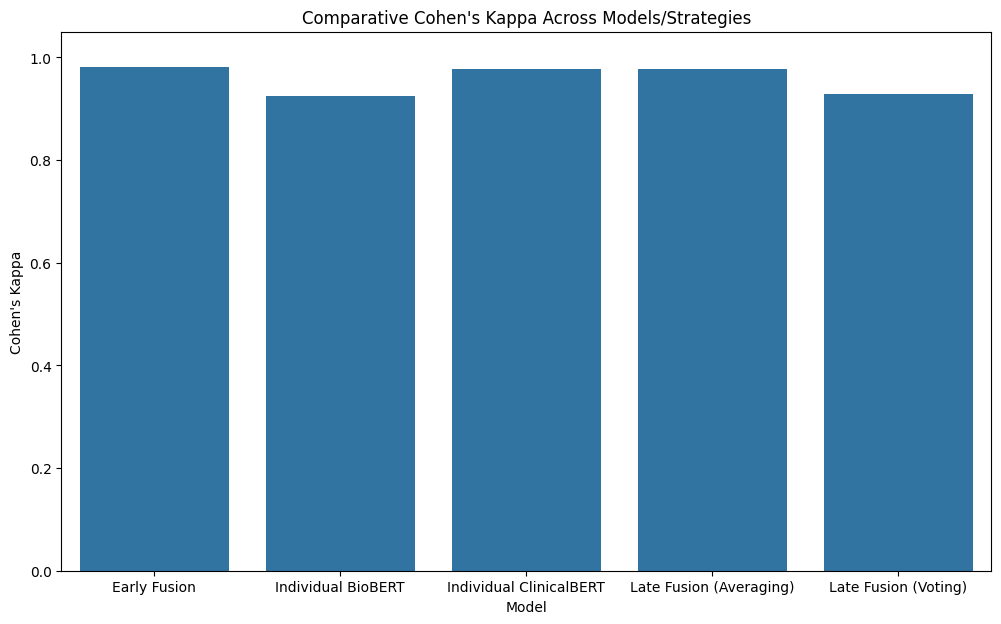

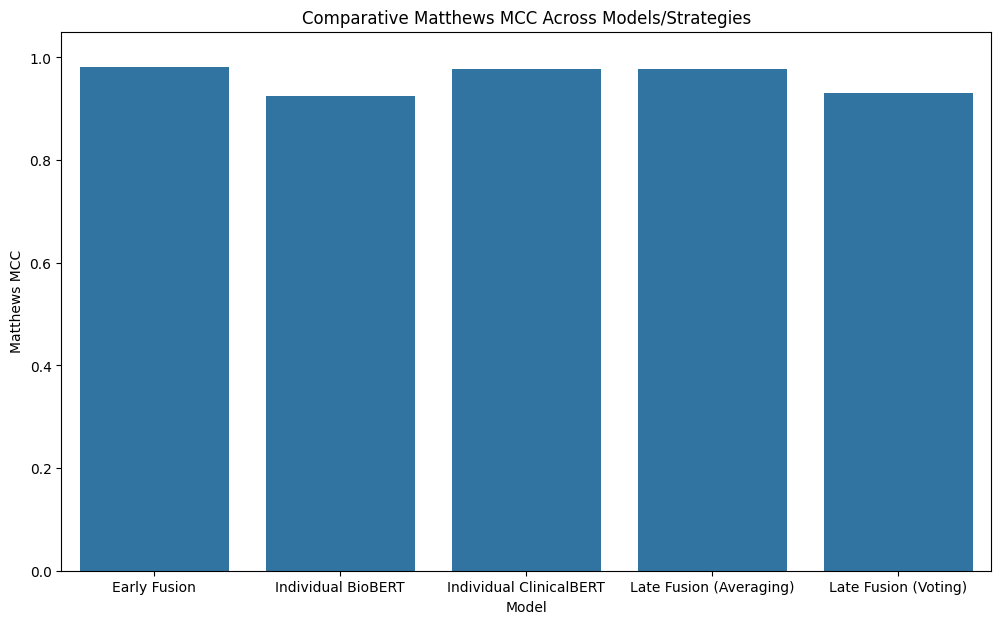

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, matthews_corrcoef
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate

def evaluate_model(model_name, true_labels, predictions, num_labels, id_to_label):
    print(f"\n--- Evaluation for {model_name} ---")

    
    predictions = np.array(predictions)
    true_labels = np.array(true_labels)

  
    accuracy = evaluate.load("accuracy").compute(predictions=predictions, references=true_labels)['accuracy']
    f1_weighted = evaluate.load("f1").compute(predictions=predictions, references=true_labels, average='weighted')['f1']
    f1_macro = evaluate.load("f1").compute(predictions=predictions, references=true_labels, average='macro')['f1']
    precision_weighted = evaluate.load("precision").compute(predictions=predictions, references=true_labels, average='weighted')['precision']
    precision_macro = evaluate.load("precision").compute(predictions=predictions, references=true_labels, average='macro')['precision']
    recall_weighted = evaluate.load("recall").compute(predictions=predictions, references=true_labels, average='weighted')['recall']
    recall_macro = evaluate.load("recall").compute(predictions=predictions, references=true_labels, average='macro')['recall']
    kappa = cohen_kappa_score(true_labels, predictions)
    mcc = matthews_corrcoef(true_labels, predictions)

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy,
        'F1_Weighted': f1_weighted,
        'F1_Macro': f1_macro,
        'Precision_Weighted': precision_weighted,
        'Precision_Macro': precision_macro,
        'Recall_Weighted': recall_weighted,
        'Recall_Macro': recall_macro,
        'Cohen_Kappa': kappa,
        'Matthews_MCC': mcc
    }

 
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-score (Weighted): {f1_weighted:.4f}")
    print(f"F1-score (Macro): {f1_macro:.4f}")
    print(f"Precision (Weighted): {precision_weighted:.4f}")
    print(f"Precision (Macro): {precision_macro:.4f}")
    print(f"Recall (Weighted): {recall_weighted:.4f}")
    print(f"Recall (Macro): {recall_macro:.4f}")
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(f"Matthews MCC: {mcc:.4f}")

    
    target_names = [str(id_to_label[i]) for i in range(num_labels)]
    print("\nClassification Report:")
    print(classification_report(true_labels, predictions, target_names=target_names, zero_division=0))

    
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return metrics

all_model_metrics = []



# Early Fusion
metrics_early = evaluate_model('Early Fusion', common_true_labels, predictions_early, num_labels, id_to_label)
all_model_metrics.append(metrics_early)

# Individual BioBERT
metrics_biobert = evaluate_model('Individual BioBERT', common_true_labels, predictions_biobert, num_labels, id_to_label)
all_model_metrics.append(metrics_biobert)

# Individual ClinicalBERT
metrics_clinicalbert = evaluate_model('Individual ClinicalBERT', common_true_labels, predictions_clinicalbert, num_labels, id_to_label)
all_model_metrics.append(metrics_clinicalbert)

# Late Fusion (Averaging)
metrics_late_avg = evaluate_model('Late Fusion (Averaging)', common_true_labels, predictions_late_fusion_avg, num_labels, id_to_label)
all_model_metrics.append(metrics_late_avg)

# Late Fusion (Voting)
metrics_late_voting = evaluate_model('Late Fusion (Voting)', common_true_labels, predictions_late_fusion_voting, num_labels, id_to_label)
all_model_metrics.append(metrics_late_voting)


metrics_df = pd.DataFrame(all_model_metrics)
metrics_df.to_csv('model_evaluation_metrics.csv', index=False)
print("\nAll model evaluation metrics saved to 'model_evaluation_metrics.csv'")


plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='F1_Weighted', data=metrics_df)
plt.title('Comparative F1-Weighted Score Across Models/Strategies')
plt.ylabel('F1-Weighted Score')
plt.ylim(0, 1.05)
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', data=metrics_df)
plt.title('Comparative Accuracy Across Models/Strategies')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Cohen_Kappa', data=metrics_df)
plt.title('Comparative Cohen\'s Kappa Across Models/Strategies')
plt.ylabel('Cohen\'s Kappa')
plt.ylim(0, 1.05)
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Matthews_MCC', data=metrics_df)
plt.title('Comparative Matthews MCC Across Models/Strategies')
plt.ylabel('Matthews MCC')
plt.ylim(0, 1.05)
plt.show()

## Calibration Metrics


Early Fusion - ECE: 0.0056, Brier Score: 0.0051
Individual BioBERT - ECE: 0.0175, Brier Score: 0.0208
Individual ClinicalBERT - ECE: 0.0130, Brier Score: 0.0074
Late Fusion (Averaging) - ECE: 0.0254, Brier Score: 0.0093

Skipping ECE and Brier Score for Late Fusion (Voting) as it relies on hard predictions, not probabilities.

Calibration Metrics DataFrame:
                     Model     ECE  Brier Score
0             Early Fusion  0.0056       0.0051
1       Individual BioBERT  0.0175       0.0208
2  Individual ClinicalBERT  0.0130       0.0074
3  Late Fusion (Averaging)  0.0254       0.0093


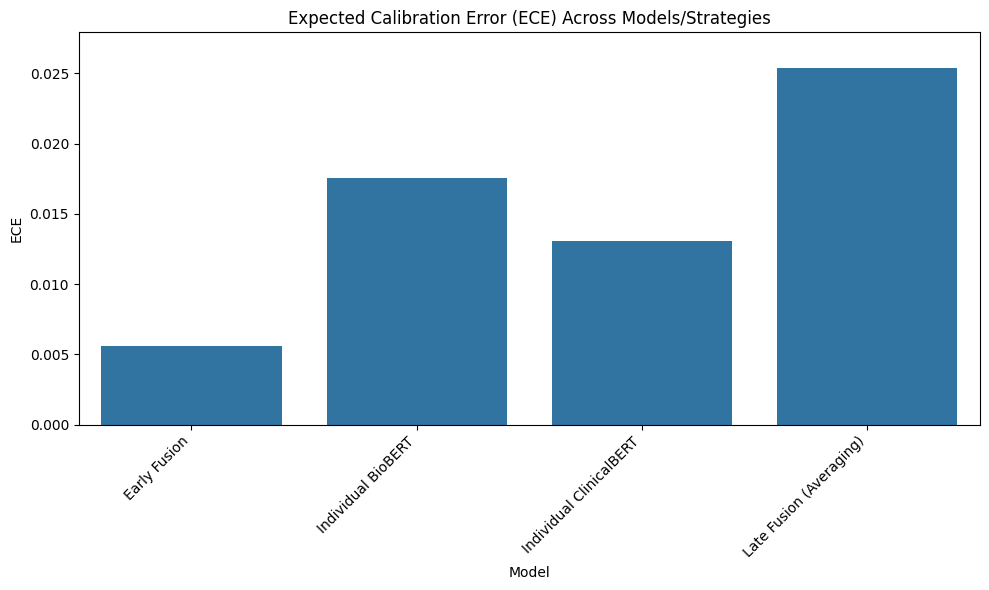

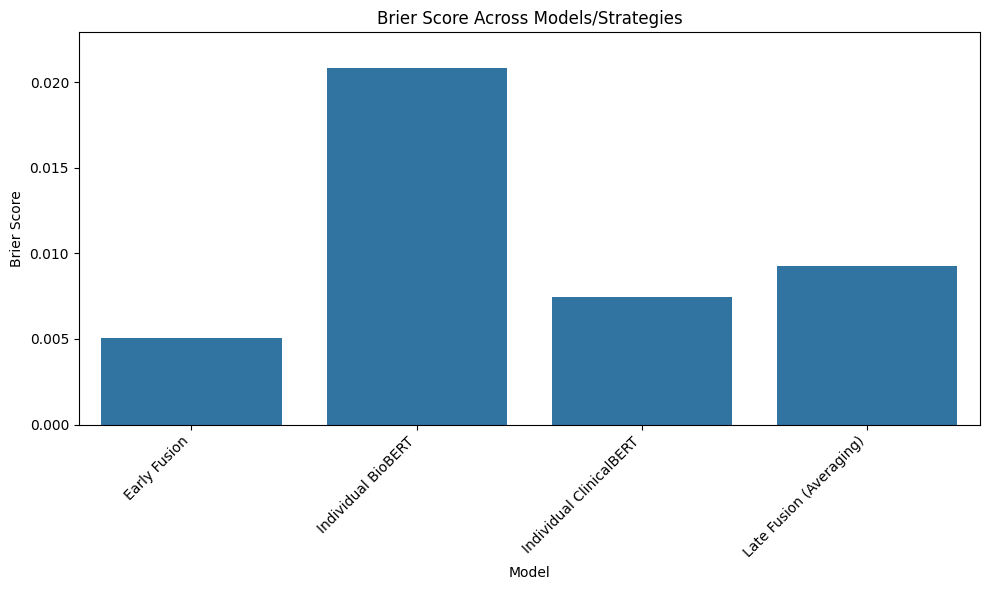

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def calculate_ece(y_true, y_prob, n_bins=10):
    y_true = np.array(y_true) 
    predictions = np.argmax(y_prob, axis=1)
    confidences = np.max(y_prob, axis=1)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    total_samples = len(y_true)

    for i in range(n_bins):
        lower_bound = bin_boundaries[i]
        upper_bound = bin_boundaries[i+1]

        
        if i == n_bins - 1: 
            bin_mask = (confidences >= lower_bound) & (confidences <= upper_bound)
        else:
            bin_mask = (confidences >= lower_bound) & (confidences < upper_bound)

        if np.any(bin_mask):
            bin_confidences = confidences[bin_mask]
            bin_predictions = predictions[bin_mask]
            bin_true_labels = y_true[bin_mask]

           
            accuracy_in_bin = np.mean(bin_predictions == bin_true_labels)
           
            avg_confidence_in_bin = np.mean(bin_confidences)

            
            bin_weight = len(bin_confidences) / total_samples
            ece += bin_weight * np.abs(accuracy_in_bin - avg_confidence_in_bin)

    return ece


def calculate_brier_score(y_true, y_prob, num_labels):
    
    y_true_one_hot = np.eye(num_labels)[y_true]
    return brier_score_loss(y_true_one_hot.ravel(), y_prob.ravel())


num_labels = len(id_to_label)


calibration_results = []

# Early Fusion model
ece_early = calculate_ece(common_true_labels, probabilities_early, n_bins=10)
brier_early = calculate_brier_score(common_true_labels, probabilities_early, num_labels)
calibration_results.append({'Model': 'Early Fusion', 'ECE': ece_early, 'Brier Score': brier_early})
print(f"Early Fusion - ECE: {ece_early:.4f}, Brier Score: {brier_early:.4f}")

# Individual BioBERT model
ece_biobert = calculate_ece(common_true_labels, probabilities_biobert, n_bins=10)
brier_biobert = calculate_brier_score(common_true_labels, probabilities_biobert, num_labels)
calibration_results.append({'Model': 'Individual BioBERT', 'ECE': ece_biobert, 'Brier Score': brier_biobert})
print(f"Individual BioBERT - ECE: {ece_biobert:.4f}, Brier Score: {brier_biobert:.4f}")

# Individual ClinicalBERT model
ece_clinicalbert = calculate_ece(common_true_labels, probabilities_clinicalbert, n_bins=10)
brier_clinicalbert = calculate_brier_score(common_true_labels, probabilities_clinicalbert, num_labels)
calibration_results.append({'Model': 'Individual ClinicalBERT', 'ECE': ece_clinicalbert, 'Brier Score': brier_clinicalbert})
print(f"Individual ClinicalBERT - ECE: {ece_clinicalbert:.4f}, Brier Score: {brier_clinicalbert:.4f}")

# Late Fusion (Averaging) model
probabilities_late_fusion_avg_calc = (probabilities_biobert + probabilities_clinicalbert) / 2


ece_late_avg = calculate_ece(common_true_labels, probabilities_late_fusion_avg_calc, n_bins=10)
brier_late_avg = calculate_brier_score(common_true_labels, probabilities_late_fusion_avg_calc, num_labels)
calibration_results.append({'Model': 'Late Fusion (Averaging)', 'ECE': ece_late_avg, 'Brier Score': brier_late_avg})
print(f"Late Fusion (Averaging) - ECE: {ece_late_avg:.4f}, Brier Score: {brier_late_avg:.4f}")


print("\nSkipping ECE and Brier Score for Late Fusion (Voting) as it relies on hard predictions, not probabilities.")

calibration_df = pd.DataFrame(calibration_results)
print("\nCalibration Metrics DataFrame:")
print(calibration_df.round(4))


plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='ECE', data=calibration_df)
plt.title('Expected Calibration Error (ECE) Across Models/Strategies')
plt.ylabel('ECE')
plt.ylim(0, calibration_df['ECE'].max() * 1.1) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Brier Score', data=calibration_df)
plt.title('Brier Score Across Models/Strategies')
plt.ylabel('Brier Score')
plt.ylim(0, calibration_df['Brier Score'].max() * 1.1) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Statistical Analysis



In [ ]:
import numpy as np
import evaluate


def bootstrap_metric(y_true, y_pred, metric_function, n_bootstraps=1000, confidence_level=0.95):
    bootstrapped_scores = []
    n_samples = len(y_true)

    for _ in range(n_bootstraps):
       
        indices = np.random.choice(n_samples, n_samples, replace=True)
        sample_y_true = np.array(y_true)[indices]
        sample_y_pred = np.array(y_pred)[indices]

        
        score = metric_function.compute(predictions=sample_y_pred, references=sample_y_true, average='macro')['f1']
        bootstrapped_scores.append(score)

 
    alpha = (1.0 - confidence_level) / 2.0
    lower_percentile = alpha * 100
    upper_percentile = (1.0 - alpha) * 100
    lower_bound = np.percentile(bootstrapped_scores, lower_percentile)
    upper_bound = np.percentile(bootstrapped_scores, upper_percentile)

    return lower_bound, upper_bound


f1_macro_metric = evaluate.load("f1")

print("Bootstrap metric function defined and F1 (macro) metric loaded.")

Bootstrap metric function defined and F1 (macro) metric loaded.


In [ ]:
print("\n--- Bootstrapping 95% Confidence Intervals for Macro F1 Score ---")

# Early Fusion
lower_bound_early, upper_bound_early = bootstrap_metric(common_true_labels, predictions_early, f1_macro_metric)
print(f"Early Fusion Macro F1 CI: [{lower_bound_early:.4f}, {upper_bound_early:.4f}]")

# Individual BioBERT
lower_bound_biobert, upper_bound_biobert = bootstrap_metric(common_true_labels, predictions_biobert, f1_macro_metric)
print(f"Individual BioBERT Macro F1 CI: [{lower_bound_biobert:.4f}, {upper_bound_biobert:.4f}]")

# Individual ClinicalBERT
lower_bound_clinicalbert, upper_bound_clinicalbert = bootstrap_metric(common_true_labels, predictions_clinicalbert, f1_macro_metric)
print(f"Individual ClinicalBERT Macro F1 CI: [{lower_bound_clinicalbert:.4f}, {upper_bound_clinicalbert:.4f}]")

# Late Fusion (Averaging)
lower_bound_late_avg, upper_bound_late_avg = bootstrap_metric(common_true_labels, predictions_late_fusion_avg, f1_macro_metric)
print(f"Late Fusion (Averaging) Macro F1 CI: [{lower_bound_late_avg:.4f}, {upper_bound_late_avg:.4f}]")

# Late Fusion (Voting)
predictions_late_fusion_voting_np = np.array(predictions_late_fusion_voting)
lower_bound_late_voting, upper_bound_late_voting = bootstrap_metric(common_true_labels, predictions_late_fusion_voting_np, f1_macro_metric)
print(f"Late Fusion (Voting) Macro F1 CI: [{lower_bound_late_voting:.4f}, {upper_bound_late_voting:.4f}]")


--- Bootstrapping 95% Confidence Intervals for Macro F1 Score ---
Early Fusion Macro F1 CI: [0.9718, 0.9969]
Individual BioBERT Macro F1 CI: [0.9130, 0.9658]
Individual ClinicalBERT Macro F1 CI: [0.9670, 0.9965]
Late Fusion (Averaging) Macro F1 CI: [0.9673, 0.9966]
Late Fusion (Voting) Macro F1 CI: [0.9175, 0.9670]


In [ ]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar


def mcnemar_test_comparison(model_a_name, model_b_name, y_true, predictions_a, predictions_b):
    print(f"\n--- McNemar's Test: {model_a_name} vs {model_b_name} ---")

    
    y_true = np.array(y_true)
    predictions_a = np.array(predictions_a)
    predictions_b = np.array(predictions_b)

    
    correct_a = (y_true == predictions_a)
    correct_b = (y_true == predictions_b)

   
    n01 = np.sum(~correct_a & correct_b)
    
    n10 = np.sum(correct_a & ~correct_b)

    
    n00 = np.sum(~correct_a & ~correct_b)
   
    n11 = np.sum(correct_a & correct_b)


    table = [[n11, n10],
             [n01, n00]]

    print(f"Contingency Table (rows: {model_a_name} | cols: {model_b_name}):")
    print(f"              Correct   Incorrect")
    print(f"Correct      {n11:<9} {n10:<9}")
    print(f"Incorrect    {n01:<9} {n00:<9}")

    # McNemar's test
    result = mcnemar(table, exact=False) 

    print(f"McNemar's Test Statistic: {result.statistic:.4f}")
    print(f"McNemar's p-value: {result.pvalue:.4f}")

    if result.pvalue < 0.05:
        print(f"Result: There is a statistically significant difference between {model_a_name} and {model_b_name} (p < 0.05).")
    else:
        print(f"Result: No statistically significant difference between {model_a_name} and {model_b_name} (p >= 0.05).")

print("McNemar's test comparison function defined.")


McNemar's test comparison function defined.


In [ ]:
print("\n--- Performing McNemar's Tests --- ")

# Early Fusion vs. Individual BioBERT
mcnemar_test_comparison(
    'Early Fusion',
    'Individual BioBERT',
    common_true_labels,
    predictions_early,
    predictions_biobert
)

# Early Fusion vs. Individual ClinicalBERT
mcnemar_test_comparison(
    'Early Fusion',
    'Individual ClinicalBERT',
    common_true_labels,
    predictions_early,
    predictions_clinicalbert
)

# Early Fusion vs. Late Fusion (Averaging)
mcnemar_test_comparison(
    'Early Fusion',
    'Late Fusion (Averaging)',
    common_true_labels,
    predictions_early,
    predictions_late_fusion_avg
)

# Early Fusion vs. Late Fusion (Voting)
mcnemar_test_comparison(
    'Early Fusion',
    'Late Fusion (Voting)',
    common_true_labels,
    predictions_early,
    predictions_late_fusion_voting
)

print("\nMcNemar's tests completed.")


--- Performing McNemar's Tests --- 

--- McNemar's Test: Early Fusion vs Individual BioBERT ---
Contingency Table (rows: Early Fusion | cols: Individual BioBERT):
              Correct   Incorrect
Correct      281       14       
Incorrect    1         3        
McNemar's Test Statistic: 9.6000
McNemar's p-value: 0.0019
Result: There is a statistically significant difference between Early Fusion and Individual BioBERT (p < 0.05).

--- McNemar's Test: Early Fusion vs Individual ClinicalBERT ---
Contingency Table (rows: Early Fusion | cols: Individual ClinicalBERT):
              Correct   Incorrect
Correct      294       1        
Incorrect    0         4        
McNemar's Test Statistic: 0.0000
McNemar's p-value: 1.0000
Result: No statistically significant difference between Early Fusion and Individual ClinicalBERT (p >= 0.05).

--- McNemar's Test: Early Fusion vs Late Fusion (Averaging) ---
Contingency Table (rows: Early Fusion | cols: Late Fusion (Averaging)):
              Correct 